In [108]:
from pprint import pprint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [109]:
MAIN_FOLDER = "/home/arman/it/AI_work/analyze_data/perfume"

In [110]:
data = pd.read_csv(f"{MAIN_FOLDER}/dataset/cleaned_perfume.csv")
print(data.shape)
data.head()

(1997, 12)


,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,is_man,country
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States",True,United States
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada",True,Canada
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States",True,United States
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States",True,United States
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,0.0,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States",True,United States


In [111]:
data["sold"] = pd.to_numeric(data["sold"], errors="coerce").fillna(0)
data["available"] = pd.to_numeric(data["available"], errors="coerce").fillna(0)
data["price"] = pd.to_numeric(data["price"], errors="coerce")

расчитаем метрики товаров

In [112]:
data["full_amount"] = data["sold"] + data["available"]
data["revenue"] = data["price"] * data["sold"] # revenue - выручка
data["potential_revenue"] = data["price"] * data["full_amount"]
data["fraction_of_sold"] = np.where(  # чтобы нам не делить, на ноль
    data["full_amount"] > 0,
    data["sold"] / data["full_amount"],
    0.0,
)
data["normed_sold"] = data["sold"] / data["sold"].max() # нормируем sold по масштабу в диапазон [0, 1]
data["demand_score"] = 0.6 * data["normed_sold"] + 0.4 * data["fraction_of_sold"] # Составной индекс спроса
# абсолютный спрос важнее

data["inventory_risk"] = np.where( # риск что товар не распродастся
    (data["fraction_of_sold"] < 0.25),
    "High",
    (
        np.where(
            data["fraction_of_sold"] < 0.5,
            "Medium",
            "Low",
        )
    ),
)

data[[
    "brand",
    "full_amount",
    "price",
    "sold",
    "available",
    "revenue",
    "potential_revenue",
    "fraction_of_sold",
    "demand_score",
    "inventory_risk"
]].head()

,brand,full_amount,price,sold,available,revenue,potential_revenue,fraction_of_sold,demand_score,inventory_risk
0,Dior,126.0,84.99,116.0,10.0,9858.84,10708.74,0.920635,0.369542,Low
1,AS SHOW,56.0,109.99,48.0,8.0,5279.52,6159.44,0.857143,0.343390,Low
2,Unbranded,37.0,100.00,27.0,10.0,2700.00,3700.00,0.729730,0.292192,Low
3,Giorgio Armani,161.0,44.99,159.0,2.0,7153.41,7243.39,0.987578,0.396796,Low
4,Lattafa,156.0,16.91,156.0,0.0,2637.96,2637.96,1.000000,0.401732,Low


In [113]:
segment_gender = (
    data.groupby("is_man", as_index=False)
    .agg(
        count=("title", "count"),
        avg_price=("price", "mean"),
        total_sold=("sold", "sum"),
        total_revenue=("revenue", "sum"),
        avg_fraction_of_sold=("fraction_of_sold", "mean"),
        avg_demand_score=("demand_score", "mean"),
    )
)

segment_gender

,is_man,count,avg_price,total_sold,total_revenue,avg_fraction_of_sold,avg_demand_score
0,False,998,39.894780,489363.0,13888042.98,0.797900,0.324603
1,True,999,46.472513,758559.0,25637660.49,0.805093,0.330466


In [114]:
segment_type = (
    data.groupby("type", as_index=False)
    .agg(
        count=("title", "count"),
        avg_price=("price", "mean"),
        total_sold=("sold", "sum"),
        total_revenue=("revenue", "sum"),
        avg_fraction_of_sold=("fraction_of_sold", "mean"),
        avg_demand_score=("demand_score", "mean"),
    )
    .sort_values("total_revenue", ascending=False)
)

segment_type.head(10)

,type,count,avg_price,total_sold,total_revenue,avg_fraction_of_sold,avg_demand_score
53,Eau de Toilette,629,38.142830,733114.0,23941880.27,0.844212,0.350623
45,Eau de Parfum,846,48.513936,265615.0,9323032.71,0.792663,0.320550
107,Unknown,4,65.662500,54099.0,1294876.40,0.713710,0.435614
43,Eau de Cologne,93,42.011828,51536.0,1029358.63,0.769162,0.313816
52,Eau de Perfume,33,34.478485,22917.0,709082.33,0.844561,0.345533
51,Eau de Parfume,2,25.840000,21211.0,541848.27,0.988904,0.513287
34,Eau De Parfum,31,67.306452,4814.0,374728.86,0.764804,0.307645
90,Perfume,105,35.991429,15988.0,314910.15,0.758479,0.305082
44,"Eau de Cologne Spray, Cologne Spray",1,33.990000,6634.0,225489.66,0.977169,0.464508
48,"Eau de Parfum, Spray",1,34.280000,5901.0,202286.28,1.000000,0.465504


In [115]:
country_metrics = (
    data.groupby("country", as_index=False)
    .agg(
        count=("title", "count"),
        avg_price=("price", "mean"),
        total_sold=("sold", "sum"),
        total_revenue=("revenue", "sum"),
        avg_fraction_of_sold=("fraction_of_sold", "mean"),
        avg_demand_score=("demand_score", "mean"),
    )
    .sort_values("total_revenue", ascending=False)
)

country_metrics.head(15)

,country,count,avg_price,total_sold,total_revenue,avg_fraction_of_sold,avg_demand_score
12,United States,1832,41.777260,1241433.0,39188545.53,0.807695,0.330600
4,Hong Kong,100,62.477000,3442.0,195870.08,0.767696,0.307461
2,Canada,16,67.216875,803.0,38990.17,0.780819,0.312885
11,Taiwan,12,72.906667,362.0,24012.38,0.747513,0.299340
5,India,4,66.085000,453.0,22797.92,0.712091,0.286093
3,China,25,28.307600,878.0,18371.01,0.520720,0.208678
0,Brazil,1,99.000000,177.0,17523.00,0.956757,0.384667
6,Israel,1,192.000000,37.0,7104.00,0.840909,0.336774
1,Bulgaria,1,29.660000,163.0,4834.58,0.942197,0.378688
9,Poland,2,32.945000,100.0,3916.34,0.801587,0.321190


In [116]:
brand_metrics = (
    data.groupby("brand", as_index=False)
    .agg(
        count=("title", "count"),
        avg_price=("price", "mean"),
        total_sold=("sold", "sum"),
        total_available=("available", "sum"),
        total_revenue=("revenue", "sum"),
        avg_fraction_of_sold=("fraction_of_sold", "mean"),
        avg_demand_score=("demand_score", "mean"),
    )
    .sort_values("total_revenue", ascending=False)
)

brand_metrics.head(15)

,brand,count,avg_price,total_sold,total_available,total_revenue,avg_fraction_of_sold,avg_demand_score
372,Versace,53,36.890755,128077.0,1041.0,4462322.28,0.879129,0.378476
74,Calvin Klein,34,24.866471,145672.0,1539.0,3767046.48,0.881738,0.400254
101,Davidoff,11,24.415455,60289.0,59.0,1682640.80,0.933198,0.434119
44,Azzaro,15,42.802000,38305.0,266.0,1673078.61,0.878894,0.379905
64,Burberry,33,40.329091,38001.0,1026.0,1220643.65,0.771245,0.321281
106,Dolce & Gabbana,23,39.268696,28570.0,423.0,1090757.30,0.899858,0.373732
293,Paco Rabanne,47,59.397234,23506.0,534.0,1071818.83,0.780575,0.317782
382,Yves Saint Laurent,55,58.996000,13895.0,701.0,995727.09,0.756213,0.305289
32,Armaf,42,39.587143,27120.0,975.0,967786.79,0.832860,0.340312
320,Ralph Lauren,50,38.419400,20849.0,1705.0,938143.86,0.787266,0.319535


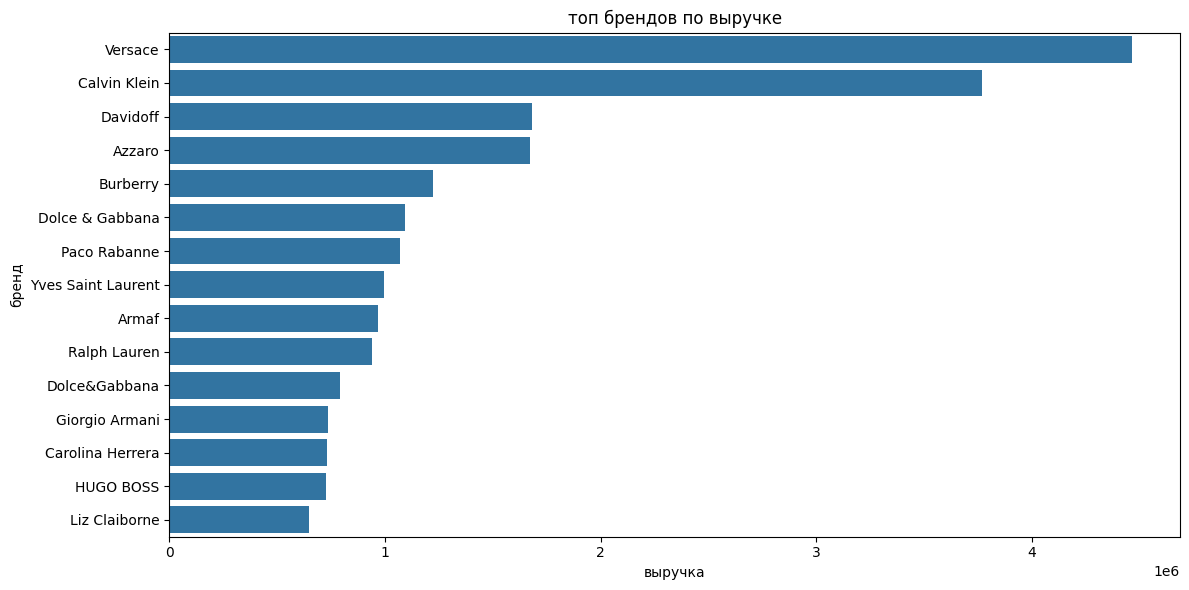

In [117]:
top_brands = brand_metrics.head(15)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_brands, x="total_revenue", y="brand")
plt.title("топ брендов по выручке")
plt.xlabel("выручка")
plt.ylabel("бренд")
plt.tight_layout()
plt.show()

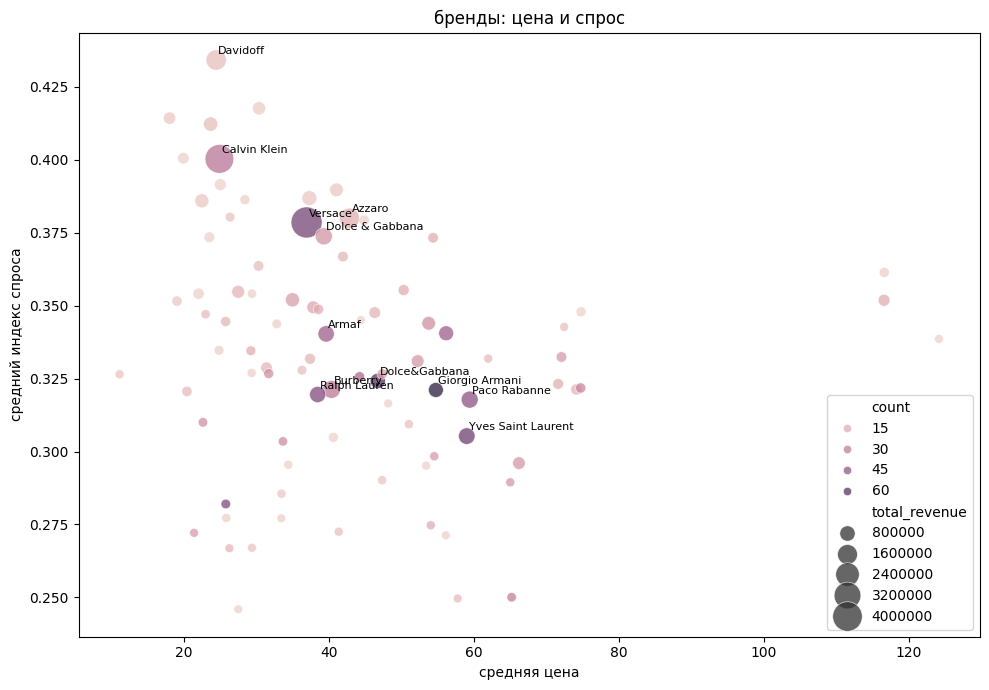

In [118]:
plot_df = brand_metrics[brand_metrics["count"] >= 5]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="avg_price",
    y="avg_demand_score",
    size="total_revenue",
    hue="count",
    sizes=(40, 500),
    alpha=0.75,
)

for _, row in plot_df.head(12).iterrows():
    plt.text(row["avg_price"] + 0.3, row["avg_demand_score"] + 0.002, row["brand"], fontsize=8)

plt.title("бренды: цена и спрос")
plt.xlabel("средняя цена")
plt.ylabel("средний индекс спроса")
plt.tight_layout()
plt.show()

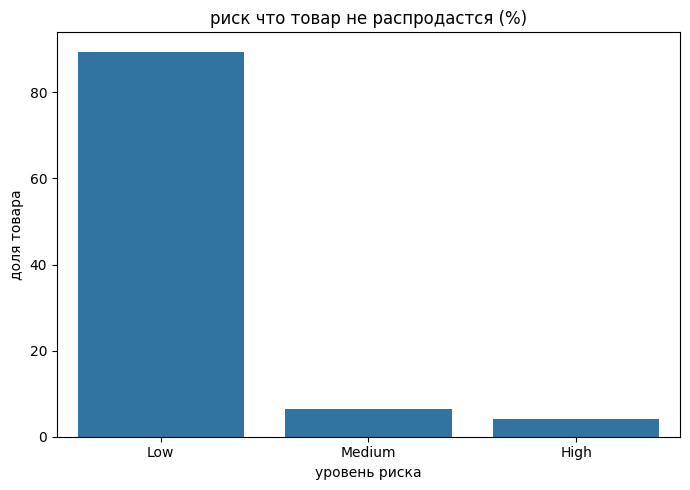

,inventory_risk,share
0,Low,89.484226
1,Medium,6.359539
2,High,4.156234


In [120]:
risk_share = (
    data["inventory_risk"]
    .value_counts(normalize=True)
    .rename("share")
    .mul(100)
    .reset_index()
    .rename(columns={"index": "risk_level"})
)

plt.figure(figsize=(7, 5))
sns.barplot(data=risk_share, x="inventory_risk", y="share")
plt.title("риск что товар не распродастся (%)")
plt.xlabel("уровень риска")
plt.ylabel("доля товара")
plt.tight_layout()
plt.show()
risk_share